In [9]:
# ==========================================
# 1. LOAD DATASET
# ==========================================

import pandas as pd
import numpy as np

df = pd.read_csv("vgsales.csv")

print("Dataset berhasil dimuat.")
print("Ukuran dataset:", df.shape)

display(df.head())

Dataset berhasil dimuat.
Ukuran dataset: (16598, 11)


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [10]:
# ==========================================
# 2. EXPLORATORY DATA ANALYSIS
# ==========================================

print("===== INFORMASI DATASET =====")
print(df.info())

print("\n===== 5 DATA TERATAS =====")
display(df.head())

print("\n===== 5 DATA TERBAWAH =====")
display(df.tail())

print("\n===== TIPE DATA =====")
print(df.dtypes)

print("\n===== JUMLAH MISSING VALUE =====")
print(df.isnull().sum())

print("\n===== JUMLAH DATA DUPLIKAT =====")
print(df.duplicated().sum())

print("\n===== JUMLAH KATEGORI GENRE =====")
print(df["Genre"].nunique())

print("\n===== DISTRIBUSI GENRE =====")
print(df["Genre"].value_counts())

===== INFORMASI DATASET =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB
None

===== 5 DATA TERATAS =====


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37



===== 5 DATA TERBAWAH =====


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
16593,16596,Woody Woodpecker in Crazy Castle 5,GBA,2002.0,Platform,Kemco,0.01,0.00,0.0,0.0,0.01
16594,16597,Men in Black II: Alien Escape,GC,2003.0,Shooter,Infogrames,0.01,0.00,0.0,0.0,0.01
16595,16598,SCORE International Baja 1000: The Official Game,PS2,2008.0,Racing,Activision,0.00,0.00,0.0,0.0,0.01
16596,16599,Know How 2,DS,2010.0,Puzzle,7G//AMES,0.00,0.01,0.0,0.0,0.01
16597,16600,Spirits & Spells,GBA,2003.0,Platform,Wanadoo,0.01,0.00,0.0,0.0,0.01



===== TIPE DATA =====
Rank              int64
Name             object
Platform         object
Year            float64
Genre            object
Publisher        object
NA_Sales        float64
EU_Sales        float64
JP_Sales        float64
Other_Sales     float64
Global_Sales    float64
dtype: object

===== JUMLAH MISSING VALUE =====
Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64

===== JUMLAH DATA DUPLIKAT =====
0

===== JUMLAH KATEGORI GENRE =====
12

===== DISTRIBUSI GENRE =====
Genre
Action          3316
Sports          2346
Misc            1739
Role-Playing    1488
Shooter         1310
Adventure       1286
Racing          1249
Platform         886
Simulation       867
Fighting         848
Strategy         681
Puzzle           582
Name: count, dtype: int64


In [11]:
# ==========================================
# 3. HANDLE MISSING VALUE
# ==========================================

# Year → median
df["Year"] = df["Year"].fillna(df["Year"].median())

# Publisher → mode
df["Publisher"] = df["Publisher"].fillna(df["Publisher"].mode()[0])

print("Missing value setelah handling:")
print(df.isnull().sum())

Missing value setelah handling:
Rank            0
Name            0
Platform        0
Year            0
Genre           0
Publisher       0
NA_Sales        0
EU_Sales        0
JP_Sales        0
Other_Sales     0
Global_Sales    0
dtype: int64


In [12]:
# ==========================================
# 4. CEK OUTLIER
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = [
    "Year",
    "NA_Sales",
    "EU_Sales",
    "JP_Sales",
    "Other_Sales",
    "Global_Sales"
]

outlier_summary = {}

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    
    outlier_summary[col] = outliers

print("Jumlah outlier:")
for col, jumlah in outlier_summary.items():
    print(f"{col}: {jumlah}")


Jumlah outlier:
Year: 305
NA_Sales: 1681
EU_Sales: 2081
JP_Sales: 2425
Other_Sales: 1665
Global_Sales: 1893


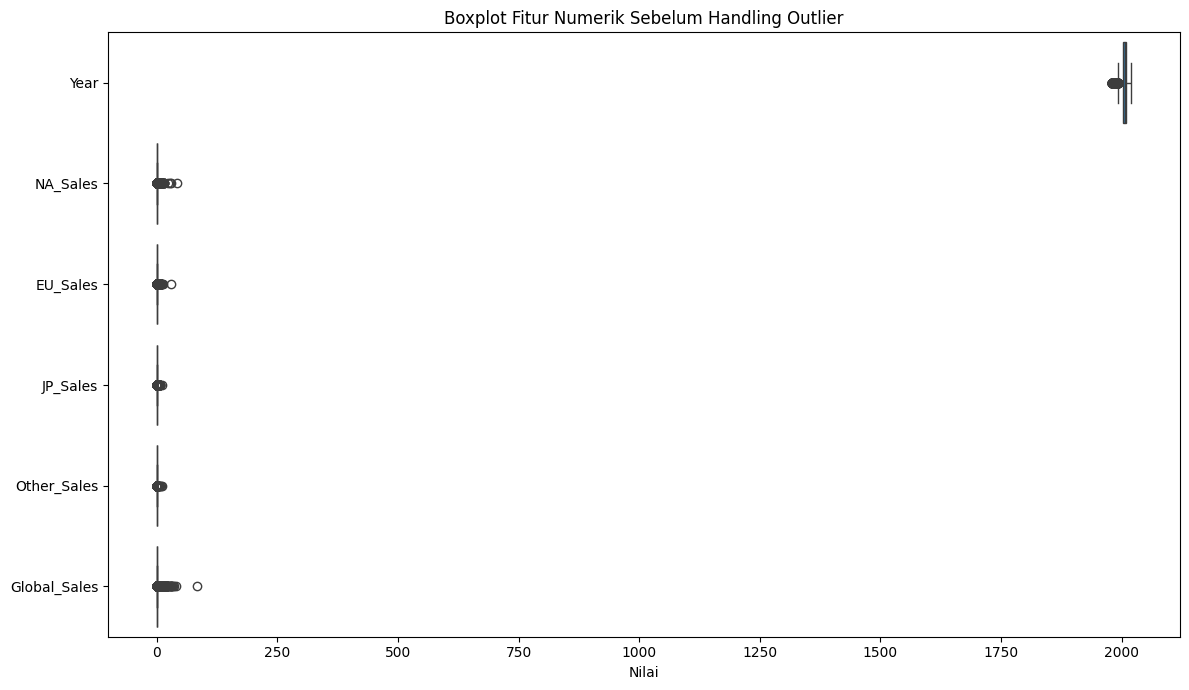

In [13]:
# ==========================================
# 5. BOXPLOT SEBELUM HANDLING OUTLIER
# ==========================================

plt.figure(figsize=(12, 7))

sns.boxplot(
    data=df[numeric_cols],
    orient="h"
)

plt.title("Boxplot Fitur Numerik Sebelum Handling Outlier")
plt.xlabel("Nilai")
plt.tight_layout()
plt.show()

In [14]:
# ==========================================
# 6. HANDLING OUTLIER DENGAN CAPPING
# ==========================================

df_handled = df.copy()

for col in numeric_cols:
    
    Q1 = df_handled[col].quantile(0.25)
    Q3 = df_handled[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df_handled[col] = df_handled[col].clip(
        lower=lower,
        upper=upper
    )

print("Handling outlier selesai.")

Handling outlier selesai.


In [15]:
# ==========================================
# 7. CEK OUTLIER SETELAH HANDLING
# ==========================================

outlier_after = {}

for col in numeric_cols:
    
    Q1 = df_handled[col].quantile(0.25)
    Q3 = df_handled[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = (
        (df_handled[col] < lower) |
        (df_handled[col] > upper)
    ).sum()
    
    outlier_after[col] = outliers

print("Jumlah outlier setelah handling:")

for col, jumlah in outlier_after.items():
    print(f"{col}: {jumlah}")

Jumlah outlier setelah handling:
Year: 0
NA_Sales: 0
EU_Sales: 0
JP_Sales: 0
Other_Sales: 0
Global_Sales: 0


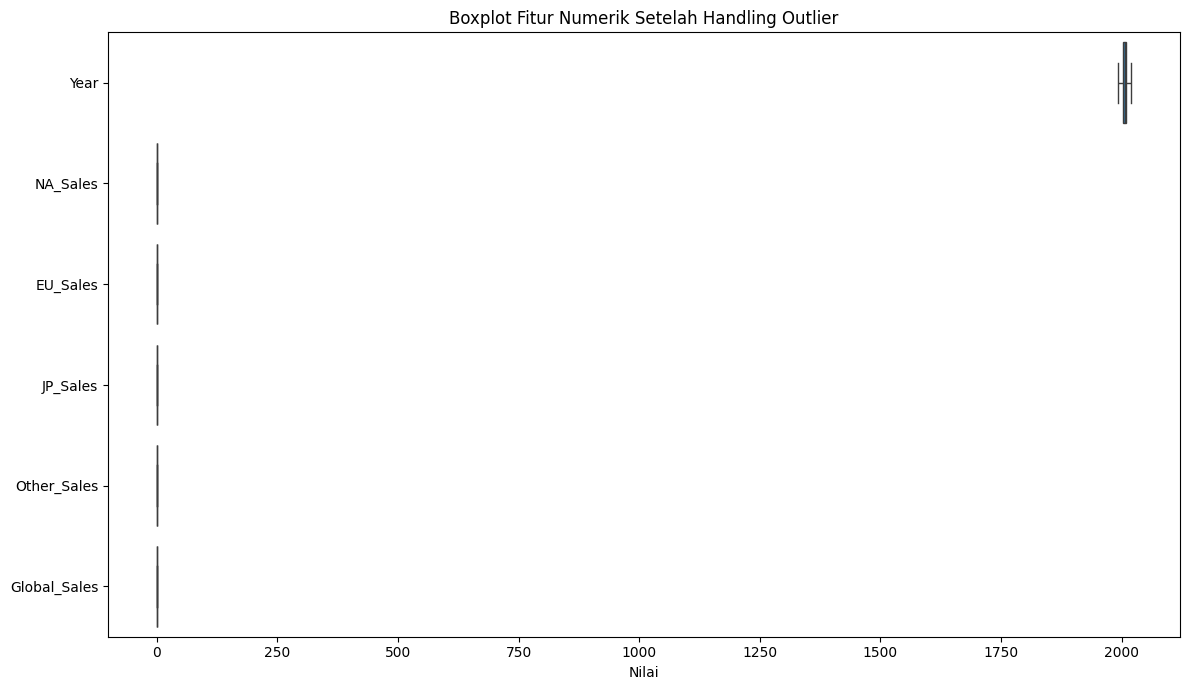

In [16]:
# ==========================================
# 8. BOXPLOT SETELAH HANDLING
# ==========================================

plt.figure(figsize=(12, 7))

sns.boxplot(
    data=df_handled[numeric_cols],
    orient="h"
)

plt.title("Boxplot Fitur Numerik Setelah Handling Outlier")
plt.xlabel("Nilai")
plt.tight_layout()
plt.show()

In [17]:
# ==========================================
# 9. FEATURE DAN TARGET
# ==========================================

target = "Genre"

features = [
    "Platform",
    "Year",
    "Publisher",
    "NA_Sales",
    "EU_Sales",
    "JP_Sales",
    "Other_Sales",
    "Global_Sales"
]

X = df_handled[features]
y = df_handled[target]

print("Fitur yang digunakan:")
print(features)

print("\nTarget:")
print(target)

print("\nUkuran X:", X.shape)
print("Ukuran y:", y.shape)

Fitur yang digunakan:
['Platform', 'Year', 'Publisher', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']

Target:
Genre

Ukuran X: (16598, 8)
Ukuran y: (16598,)


In [18]:
# ==========================================
# 10. TRAIN TEST SPLIT
# ==========================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Jumlah data training:", len(X_train))
print("Jumlah data testing :", len(X_test))

Jumlah data training: 13278
Jumlah data testing : 3320


In [19]:
# ==========================================
# 11. PEMISAHAN FITUR
# ==========================================

categorical_cols = [
    "Platform",
    "Publisher"
]

numeric_cols_model = [
    "Year",
    "NA_Sales",
    "EU_Sales",
    "JP_Sales",
    "Other_Sales",
    "Global_Sales"
]

print("Fitur kategorikal:")
print(categorical_cols)

print("\nFitur numerik:")
print(numeric_cols_model)

Fitur kategorikal:
['Platform', 'Publisher']

Fitur numerik:
['Year', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']


In [20]:
# ==========================================
# 12. PREPROCESSING
# ==========================================

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_cols
        ),
        (
            "numeric",
            StandardScaler(),
            numeric_cols_model
        )
    ]
)

print("Preprocessing berhasil dibuat.")

Preprocessing berhasil dibuat.


In [21]:
# ==========================================
# 13. MODEL
# ==========================================

from sklearn.ensemble import GradientBoostingClassifier

model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

print(model)

GradientBoostingClassifier(random_state=42)


In [22]:
# ==========================================
# 14. PIPELINE
# ==========================================

from sklearn.pipeline import Pipeline

pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("model", model)
    ]
)

print("Pipeline berhasil dibuat.")

Pipeline berhasil dibuat.


In [23]:
# ==========================================
# 15. TRAINING
# ==========================================

print("Memulai proses training...")

pipeline.fit(
    X_train,
    y_train
)

print("Training selesai.")

Memulai proses training...
Training selesai.


In [24]:
# ==========================================
# 16. PREDIKSI
# ==========================================

y_pred = pipeline.predict(X_test)

print("Prediksi selesai.")

print("\n10 hasil prediksi pertama:")
print(y_pred[:10])

Prediksi selesai.

10 hasil prediksi pertama:
['Adventure' 'Puzzle' 'Misc' 'Misc' 'Action' 'Sports' 'Sports' 'Action'
 'Strategy' 'Sports']


In [25]:
# ==========================================
# 17. ACCURACY
# ==========================================

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    y_pred
)

print(f"Akurasi Model: {accuracy:.4f}")
print(f"Akurasi Model: {accuracy * 100:.2f}%")

Akurasi Model: 0.3645
Akurasi Model: 36.45%


In [26]:
# ==========================================
# 18. CLASSIFICATION REPORT
# ==========================================

from sklearn.metrics import classification_report

print("===== CLASSIFICATION REPORT =====")

print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

      Action       0.33      0.61      0.43       663
   Adventure       0.48      0.31      0.38       257
    Fighting       0.44      0.30      0.36       170
        Misc       0.31      0.24      0.27       348
    Platform       0.34      0.21      0.26       177
      Puzzle       0.25      0.10      0.15       116
      Racing       0.40      0.20      0.27       250
Role-Playing       0.43      0.40      0.41       298
     Shooter       0.31      0.12      0.17       262
  Simulation       0.35      0.24      0.29       174
      Sports       0.39      0.57      0.46       469
    Strategy       0.36      0.21      0.27       136

    accuracy                           0.36      3320
   macro avg       0.37      0.29      0.31      3320
weighted avg       0.37      0.36      0.34      3320



In [27]:
# ==========================================
# 19. CONFUSION MATRIX
# ==========================================

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[406  19  12  38  19   3  13  26  18  15  86   8]
 [ 81  80   2  20   3   6   4  17   5   6  30   3]
 [ 56   7  51   8   3   1   4  15   3   1  18   3]
 [115  15   4  84   8   2  10  26   6  17  60   1]
 [ 78   0   5  12  37   4   3   7   4   3  22   2]
 [ 30   7   4  19   3  12   9  10   4   5  10   3]
 [ 70   2   4  15  12   6  50   7   8   2  69   5]
 [ 86  14  11  16   9   5   4 120   4   6  15   8]
 [119   1   8  15   8   0   9   9  32   4  47  10]
 [ 44   7   3  16   1   1   0  14   5  42  37   4]
 [ 98   7  10  24   5   7  19   8   8  11 267   5]
 [ 32   6   1   6   2   1   1  22   7   7  22  29]]


<Figure size 1000x800 with 0 Axes>

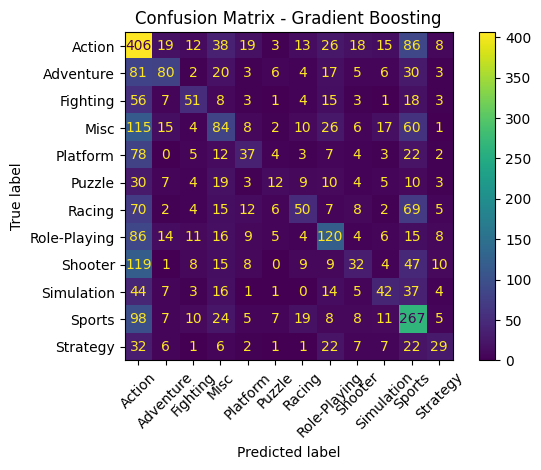

In [28]:
# ==========================================
# 20. VISUALISASI CONFUSION MATRIX
# ==========================================

from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(10, 8))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    xticks_rotation=45
)

plt.title("Confusion Matrix - Gradient Boosting")
plt.tight_layout()
plt.show()

In [29]:
# ==========================================
# 21. DISTRIBUSI TARGET
# ==========================================

print("===== DISTRIBUSI GENRE TRAINING =====")
print(y_train.value_counts(normalize=True))

print("\n===== DISTRIBUSI GENRE TESTING =====")
print(y_test.value_counts(normalize=True))

===== DISTRIBUSI GENRE TRAINING =====
Genre
Action          0.199804
Sports          0.141362
Misc            0.104760
Role-Playing    0.089622
Shooter         0.078928
Adventure       0.077497
Racing          0.075237
Platform        0.053397
Simulation      0.052192
Fighting        0.051062
Strategy        0.041045
Puzzle          0.035096
Name: proportion, dtype: float64

===== DISTRIBUSI GENRE TESTING =====
Genre
Action          0.199699
Sports          0.141265
Misc            0.104819
Role-Playing    0.089759
Shooter         0.078916
Adventure       0.077410
Racing          0.075301
Platform        0.053313
Simulation      0.052410
Fighting        0.051205
Strategy        0.040964
Puzzle          0.034940
Name: proportion, dtype: float64
